#1 - CLASIFICACIÓN CON NAIVE BAYES

#1-Importar los datos

In [1]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")
## Defino la raiz del sistema de archivos
raiz="/content/drive/MyDrive"
## Importo el archivo
solicitantes = pd.read_excel(raiz + "/0. SolicitantesCrédito.xlsx")

Mounted at /content/drive


In [2]:
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

#2-Limpieza de los datos


In [3]:
solicitantes.shape

(8378, 35)

In [4]:
## Elimino las filas donde "PreApr" esta vacío
XD=solicitantes.dropna(subset=["PreApr"])

In [5]:
XD.shape

(5842, 35)

In [6]:
# Seleccionamos solo las variables independientes del modelo
XD=XD[["Edad","Hijos","Perscargo","Estrato","Ingresos","Egresos","Monto (EAD)","Plazo","Cuota (COP)"]]

In [7]:
## Escojo la variable dependiente
yd=solicitantes["PreApr"].dropna()   ## Con un solo corchete para convertirlo fácil a arreglo

### 3. Implementación del modelo Naive Bayes


In [8]:
## Importo las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

In [9]:
# Convierto los datasets a arrays
XDArray = np.array(XD, dtype=float)
ydArray = np.array(yd, dtype=float)

In [10]:
# ENTRENAR EL MODELO
modelNB = GaussianNB()
modelNB.fit(XDArray, ydArray)

GaussianNB()

In [11]:
## Predigo los yd
ydPred=modelNB.predict(XDArray)
ydPred

array([1., 0., 0., ..., 0., 0., 1.])

# 4. Matriz de confusión

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(ydArray, ydPred)
cm

array([[2539,  420],
       [1041, 1842]])

In [13]:
cm[1][1]

1842

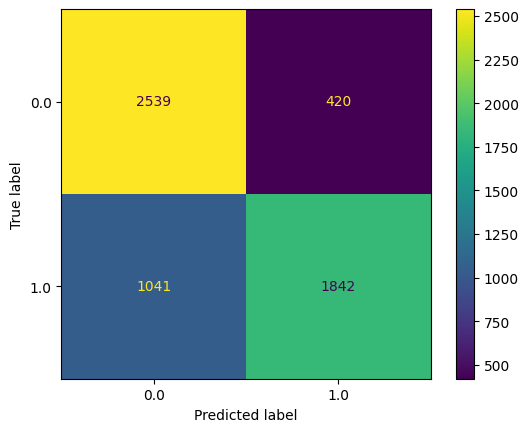

In [14]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelNB.classes_)
disp.plot()
plt.show()

## Análisis matriz
Del total de true negative (2539), se evidencia un total de 420 no clasificados correctamente mientras que del total de true positive (1842) los no clasificados correctamente son 1041. Asimismo, con base en la matriz realizada en clase, se observa como del total de true negative (2503) los no clasificados correctamente fueron 456, es decir, en esta nueva matriz se vió una disminución, a diferencia de los true positive (1945) que los no clasificados son un total de 938, lo que muestra un aumento en los resultados de la matriz actual.


### 5. Métricas de exactitud del modelo

In [15]:
## Exactitud (Accuracy)
## Número de predicciones correctas sobre el total de predicciones
exactitud = (cm[1][1] + cm[0][0])/cm.sum()
print(f"La exactitud (accuracy) del modelo es de {exactitud:.2%}")

La exactitud (accuracy) del modelo es de 74.99%


#### Análisis exactitud
Se observa que la exactitud del modelo actual es de 74.99%, es decir, son los true positive y true negative sobre el total de predicciones. A su vez, en el modelo anterior la exactitud fue de 76.14% lo que indica que hubo una leve disminución en el nuevo modelo.  


In [16]:
## TASA DE ERROR
## Número de predicciones incorrectas sobre el total de predicciones
# Opción 1
error = (cm[1][0] + cm[0][1])/cm.sum()
# Opción 2
error = 1 - exactitud
print(f"El error del modelo es de {error:.2%}")

El error del modelo es de 25.01%


#### Análisis tasa de error
Se muestra que el error de este nuevo modelo es de 25.01% y el error del modelo de clase es de 23.86% lo que evidencia un aumento significativo en los casos no clasificados correctamente (false positive y false negative) del total de predicciones.

In [17]:
## PRECISIÓN
## Que tan cerca está un resultado del valor verdadero. De los que calcula como verdaderos
## cuales son efectivamente verdaderos
precisión = cm[1][1]/(cm[1][1] + cm[0][1])
print(f"La precisión del modelo es de {precisión:.2%}")

La precisión del modelo es de 81.43%


#### Análisis precisión
Se analiza que la precisión del modelo, es decir, los resultados que calcula como verdaderos y si sean verdaderos, es de 81.43% mientras que en el modelo anterior es de 81.01%, en este caso hay un pequeño aumento lo que refleja una disminución de los false positive.

In [18]:
## SENSIBILIDAD (RECALL)
## Es la cantidad de positivos bien clasificados por el modelo
## respecto al total de positivos
sensibilidad = cm[1][1]/(cm[1][1] + cm[1][0])
print(f"La sensibilidad del modelo es de {sensibilidad:.2%}")

La sensibilidad del modelo es de 63.89%


#### Análisis sensibilidad
En este aspecto se observa la cantidad de positivos que fueron bien clasificados, en el modelo de clase la sensibilidad es de 67.46% mientras que en el modelo actual es de 63.46% lo que indica una disminución en la clasificación correcta de los mismos.

In [19]:
cm[1].sum()

2883

In [20]:
## ESPECIFICIDAD
## Es la cantidad de negativos bien clasificados por el modelo
## respecto al total de negativos
especificidad = cm[0][0]/(cm[0][1] + cm[0][0])
print(f"La especificidad del modelo es de {especificidad:.2%}")

La especificidad del modelo es de 85.81%


#### Análisis especificidad
A diferencia del anterior, en este aspecto se evidencia la cantidad de negativos que fueron bien clasificados por el modelo. En el modelo de clase, la especificidad es de 84.59% en cambio en el modelo actual es de 85.81% lo que indica una mejoría en la correcta clasificación de los negativos.

### 6. Pronóstico de la Prepaprobación para solicitantes nuevos

In [21]:
## Filtro los solicitantes que no tienen valor en PreApr
XDGener = solicitantes[solicitantes["PreApr"].isna()]
XDGener.head()

,Unnamed: 0,Edad,Sexo,Estado civil,Hijos,Perscargo,Estrato,Nivel de estudios,Tipo de contrato,Ingresos,...,Plazo,Cuota (COP),ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD
6,7,38,NR,Soltero,3,0,3,Profesional,Indefinido,1534711,...,60,2.009414e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
7,8,47,Mujer,Casado,0,0,2,Profesional,Ninguno,136750,...,48,3.563229e+03,Buena Experiencia CFB,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
11,12,46,Mujer,Casado,0,1,4,Primaria,Indefinido,7097220,...,3,1.090054e+06,Buenas Referencias,Con Codeudor(es),Prop.sin Hipoteca,Con Experiencia sin Mora,NaN,NaN,NaN,NaN
13,14,37,Mujer,Soltero,4,2,2,Técnico,Ninguno,1791987,...,48,6.856249e+04,Buena Experiencia CFB,Sin Codeudor,Prop.sin Hipoteca,Mora mayor a 60 Dìas,NaN,NaN,NaN,NaN
16,17,22,NR,Unión Libre,1,0,2,Bachiller,Fijo,2892545,...,36,6.824255e+04,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,NaN,NaN,NaN,NaN


In [22]:
XDGener = XDGener[["Edad","Hijos","Perscargo","Estrato","Ingresos","Egresos","Monto (EAD)","Plazo","Cuota (COP)"]]
XDGener.head()

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
6,38,3,0,3,1534711,1658694,7.913126e+05,60,2.009414e+04
7,47,0,0,2,136750,171155,1.213014e+05,48,3.563229e+03
11,46,0,1,4,7097220,9525257,3.174456e+06,3,1.090054e+06
13,37,4,2,2,1791987,1391431,2.334042e+06,48,6.856249e+04
16,22,1,0,2,2892545,3576891,1.887636e+06,36,6.824255e+04


In [23]:
XDGener.shape

(2536, 9)

In [24]:
## Convierto el data frame (df) a un array para poder ingresarlo al modelo GaussianNB
XDGener = np.array(XDGener, dtype=float)

In [25]:
## Solicito al modelo que me haga el pronóstico a los solicitantes
## que aún no tienen información
ydGener = modelNB.predict(XDGener)

In [26]:
ydGenerSerie = pd.Series(ydGener,  ## ingreso los valores que acabamos de predecir
                         index= solicitantes[solicitantes["PreApr"].isna()].index)  ## le pongo los indices de los solicitantes faltantes
ydGenerSerie.head()

6     0.0
7     0.0
11    1.0
13    0.0
16    0.0
dtype: float64

In [27]:
solicitantes["PreApr"].fillna(ydGenerSerie, inplace=True)

In [28]:
solicitantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8378 non-null   int64  
 1   Edad                     8378 non-null   int64  
 2   Sexo                     8378 non-null   object 
 3   Estado civil             8378 non-null   object 
 4   Hijos                    8378 non-null   int64  
 5   Perscargo                8378 non-null   int64  
 6   Estrato                  8378 non-null   int64  
 7   Nivel de estudios        8378 non-null   object 
 8   Tipo de contrato         8378 non-null   object 
 9   Ingresos                 8378 non-null   int64  
 10  Egresos                  8378 non-null   int64  
 11  Tipo de actividad        8378 non-null   object 
 12  Tipo de vivienda         8378 non-null   object 
 13  Total Activos            8378 non-null   float64
 14  Total pasivos           

In [29]:
## Exporto a la carpeta content
solicitantes.to_excel("PronosticoPreApr.xlsx")

In [30]:
## O si lo quiero exportar al drive
solicitantes.to_excel("/content/drive/MyDrive/PronosticoPreApr.xlsx")

7. Determinamos el número de registros por cada de las categorías de preaprobación

In [31]:
modelNB.class_prior_  ## Me indica que el 50,56% de los casos fueron negados y el 49,34% aprobados

array([0.50650462, 0.49349538])

In [32]:
modelNB.class_count_  ## Cuantos casos hay negados y cuantos preaprobados respectivamente

array([2959., 2883.])

In [33]:
modelNB.theta_  ## Son las medias del modelo (deben ser las mismas de las calculadas en Excel)

array([[4.09841163e+01, 1.09226090e+00, 8.70226428e-01, 2.66339980e+00,
        1.72570723e+06, 1.80697480e+06, 1.30236507e+06, 3.22903008e+01,
        7.59838492e+04],
       [4.11075269e+01, 1.05584461e+00, 8.22754076e-01, 3.17030871e+00,
        4.11995789e+06, 4.05086905e+06, 3.51540952e+06, 3.28387097e+01,
        1.94971428e+05]])

In [34]:
## CALCULAMOS LAS DESVIACIONES

In [35]:
filas_0 = np.where(ydArray==0)
filas_1 = np.where(ydArray==1)

In [36]:
desvest_0 = np.sqrt(np.var(XDArray[filas_0], axis=0))
desvest_0

array([1.22130221e+01, 1.24327359e+00, 1.04384563e+00, 8.95474371e-01,
       1.30319166e+06, 1.54247787e+06, 1.06181026e+06, 1.26987828e+01,
       1.33962404e+05])

In [37]:
desvest_1 = np.sqrt(np.var(XDArray[filas_1], axis=0))
desvest_1

array([1.22510544e+01, 1.22070373e+00, 9.97817134e-01, 1.00663398e+00,
       1.88973371e+06, 2.36445020e+06, 2.11455171e+06, 1.27223614e+01,
       2.92416070e+05])